In [1]:
# =============================================
# ПРАКТИЧЕСКАЯ РАБОТА №10
# Полиномиальная регрессия + Регуляризация (Ridge, Lasso)
# Датасет: Gas Well Production
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8')

# ====================== 1. ЗАГРУЗКА ДАННЫХ ======================
url = "https://aegis4048.github.io/downloads/notebooks/sample_data/unconv_MV_v5.csv"
df = pd.read_csv(url)

print("Размер датасета:", df.shape)
print(df.columns.tolist())
display(df.head())

Размер датасета: (200, 8)
['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod']


,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


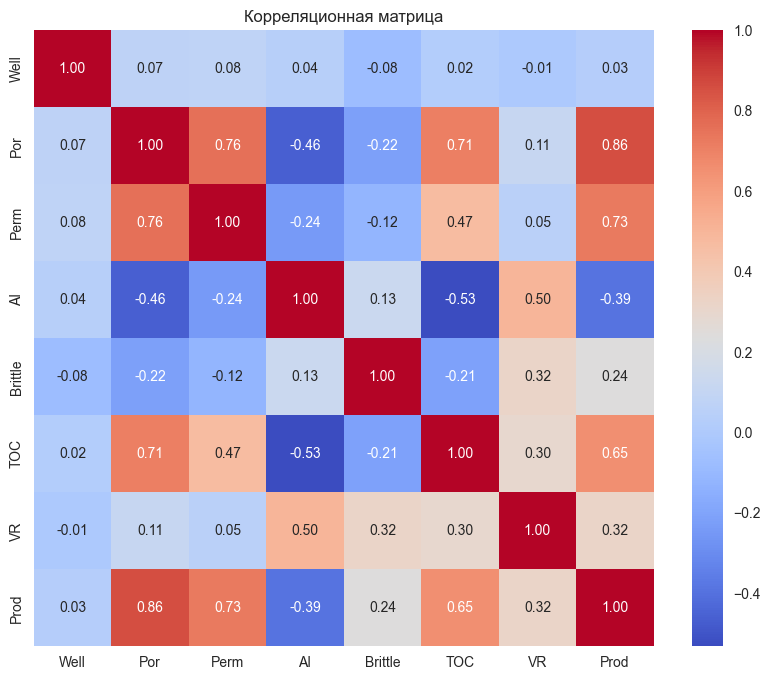

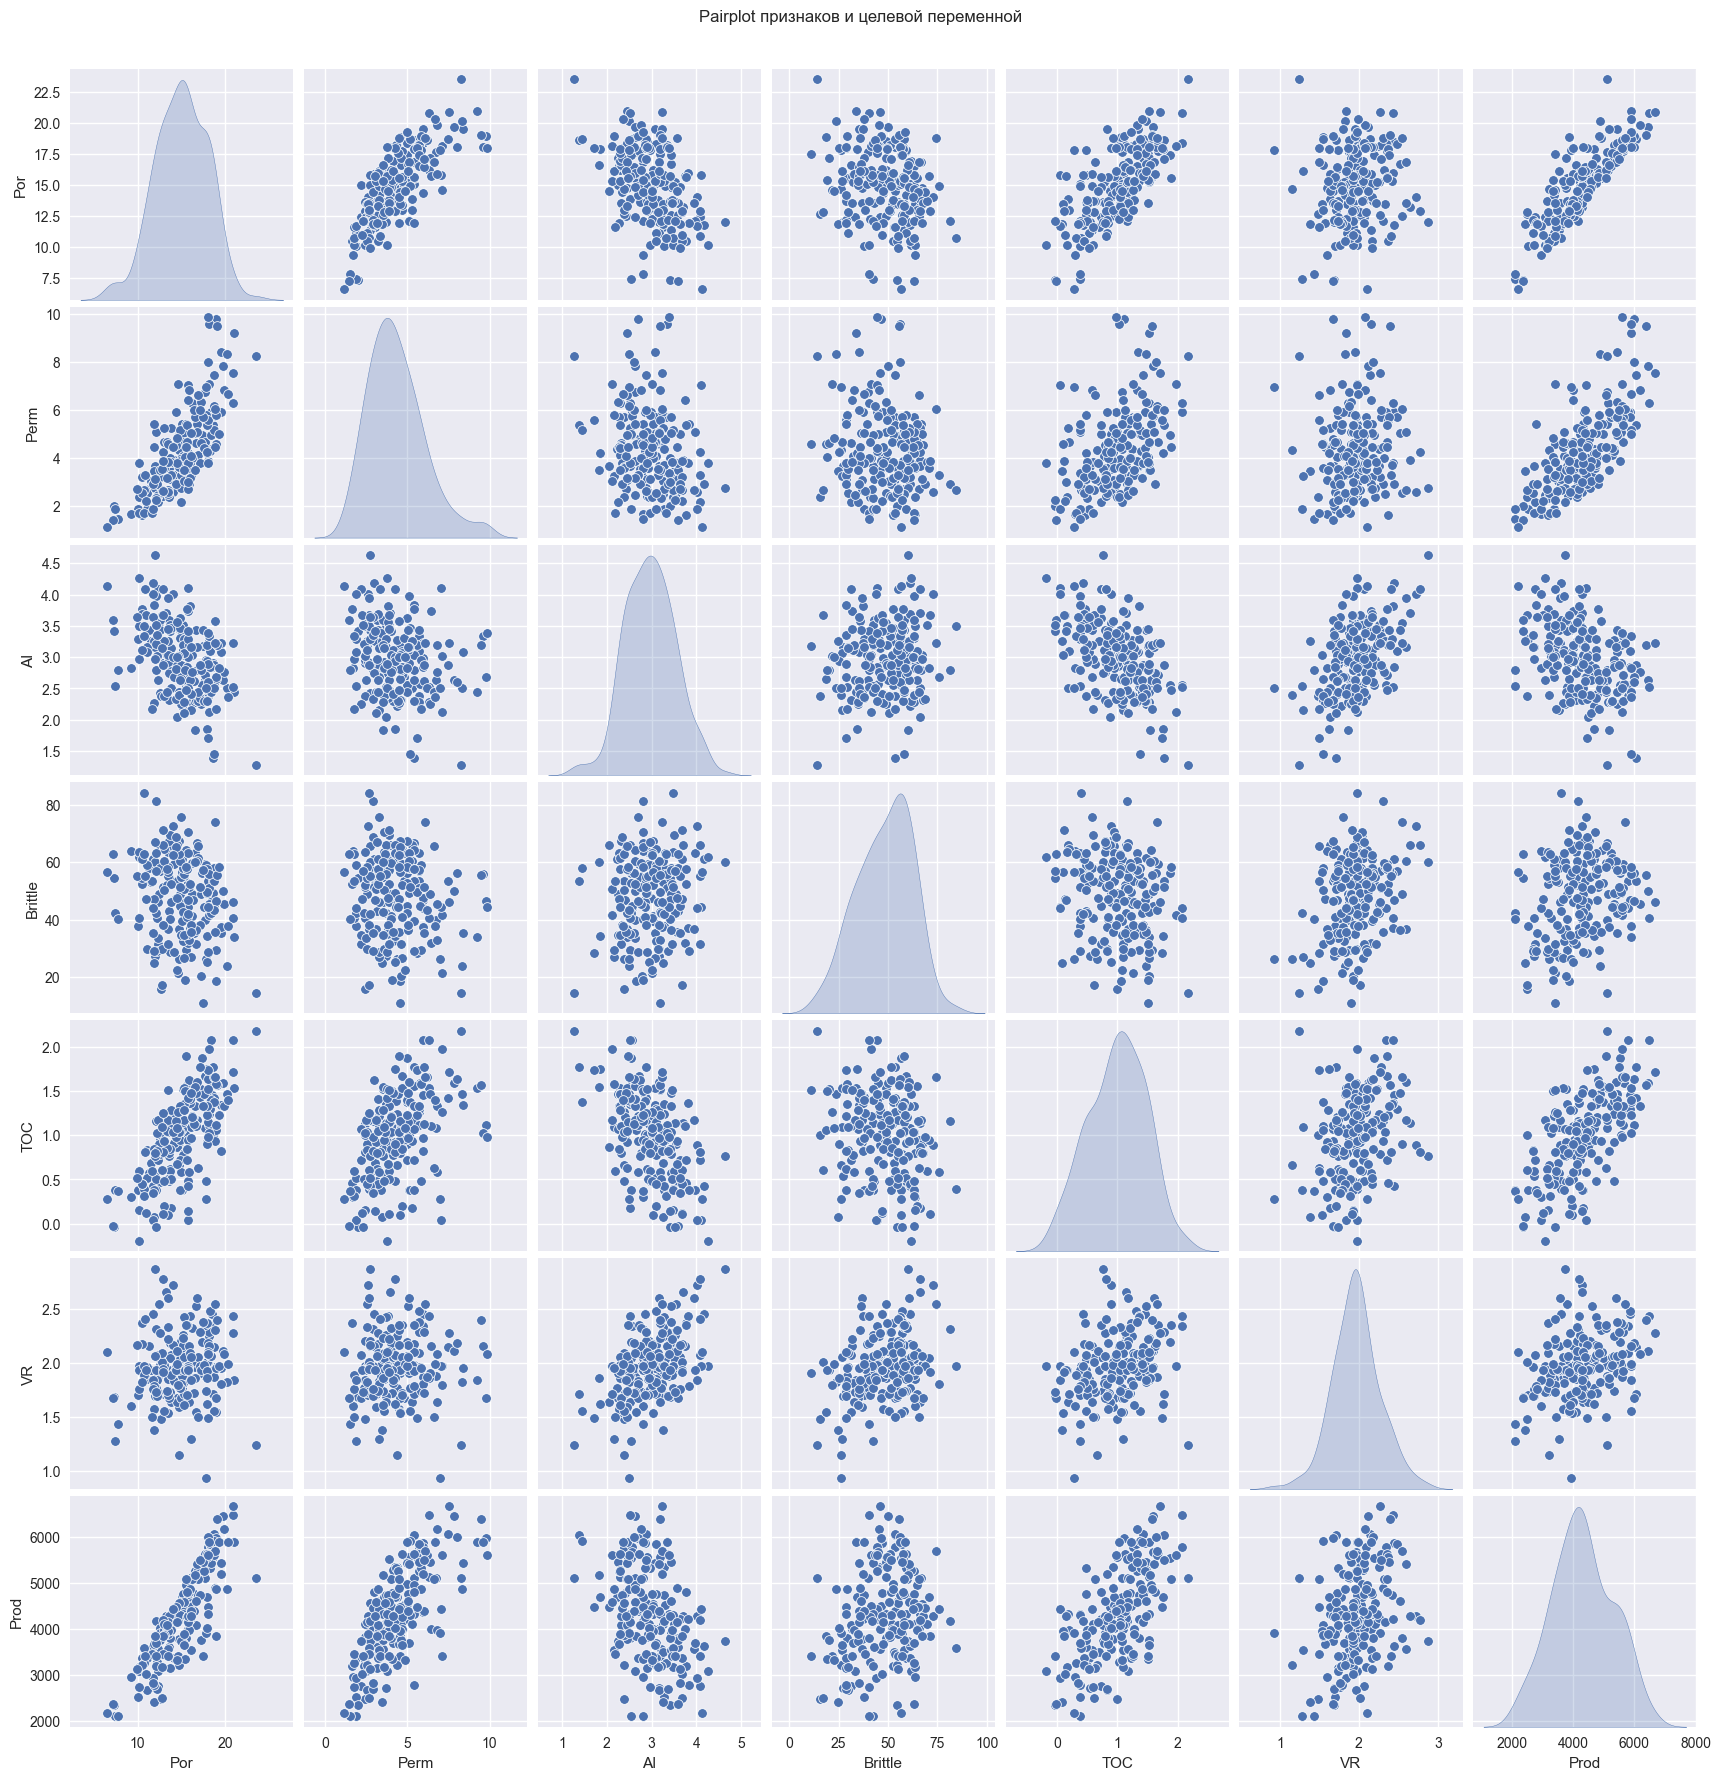

In [2]:
# ====================== 2. EDA ======================
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

# Выбираем признаки
features = ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']
X = df[features]
y = df['Prod']

sns.pairplot(df[features + ['Prod']], diag_kind='kde')
plt.suptitle('Pairplot признаков и целевой переменной', y=1.02)
plt.show()

In [3]:
# ====================== 3. Подготовка данных ======================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Degree 1: R² = 0.9506, RMSE = 204.46
Degree 2: R² = 0.9731, RMSE = 150.78
Degree 3: R² = 0.9888, RMSE = 97.49
Degree 4: R² = 0.9875, RMSE = 102.89


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


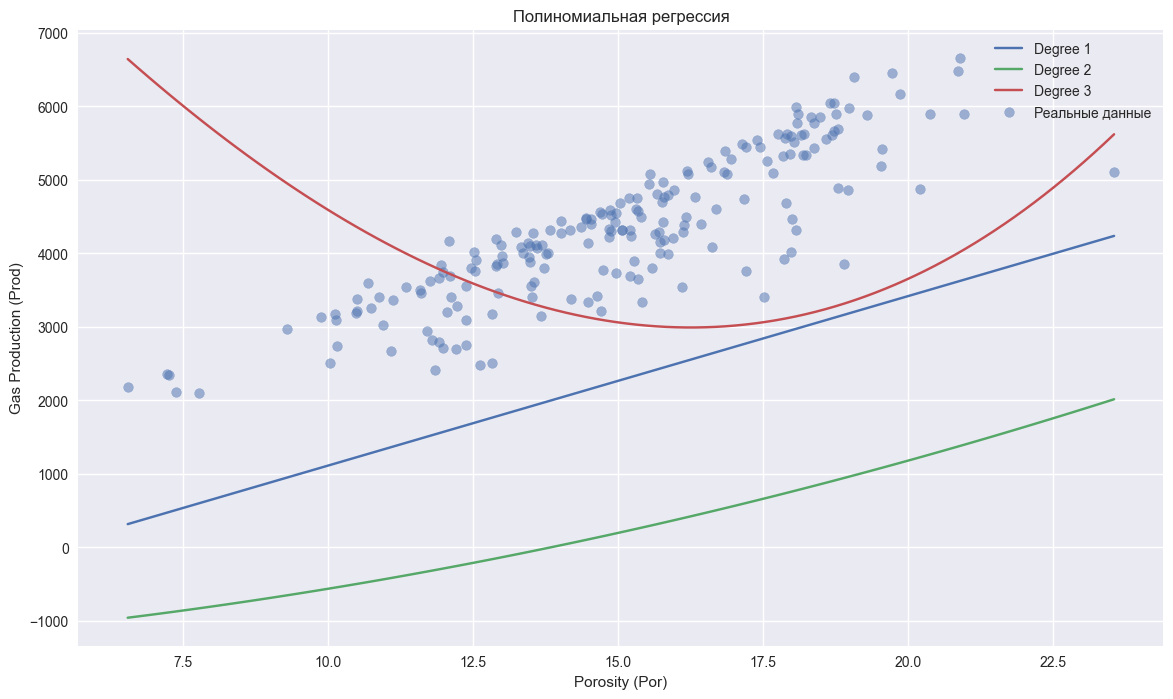

In [4]:
# ====================== 4. Полиномиальная регрессия ======================
degrees = [1, 2, 3, 4]
results = []

plt.figure(figsize=(14, 8))

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    # Обычная линейная регрессия на полиномиальных признаках
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append((degree, r2, rmse))
    
    print(f"Degree {degree}: R² = {r2:.4f}, RMSE = {rmse:.2f}")

# Визуализация (для одного признака — Por)
X_plot = np.linspace(X['Por'].min(), X['Por'].max(), 100).reshape(-1, 1)
X_plot_full = np.zeros((100, X_train.shape[1]))
X_plot_full[:, 0] = X_plot.ravel()  # Por как главный признак

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_plot_poly = poly.fit_transform(scaler.transform(X_plot_full))
    model = LinearRegression().fit(poly.fit_transform(X_train_scaled), y_train)
    y_plot = model.predict(X_plot_poly)
    plt.plot(X_plot, y_plot, label=f'Degree {degree}')

plt.scatter(df['Por'], df['Prod'], alpha=0.5, label='Реальные данные')
plt.xlabel('Porosity (Por)')
plt.ylabel('Gas Production (Prod)')
plt.title('Полиномиальная регрессия')
plt.legend()
plt.show()

In [5]:
# ====================== 5. Регуляризация (Ridge + Lasso) ======================
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1, max_iter=10000)

ridge.fit(X_train_poly, y_train)
lasso.fit(X_train_poly, y_train)

print("Ridge R²:", r2_score(y_test, ridge.predict(X_test_poly)))
print("Lasso R²:", r2_score(y_test, lasso.predict(X_test_poly)))

Ridge R²: 0.9918917977930567
Lasso R²: 0.9917931759769919
